In [ ]:
#connect to the google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ==========================================
# 1. SETUP & DATA EXTRACTION
# ==========================================
import os
import cv2
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from glob import glob
from zipfile import ZipFile

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.applications import MobileNetV2, ResNet50
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [ ]:
# Update these paths to match your Iris dataset location
zip_path = '/content/drive/MyDrive/Python /SE4050-DL-Lecture02-main/DL_Assignment/lung_images.zip'
extract_path = './extracted_data' # Extracting to local colab runtime for speed
path = './extracted_data/research_data_set' # Update this based on internal zip structure

# Extract the data
with ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
    print('The dataset has been extracted.')

The dataset has been extracted.


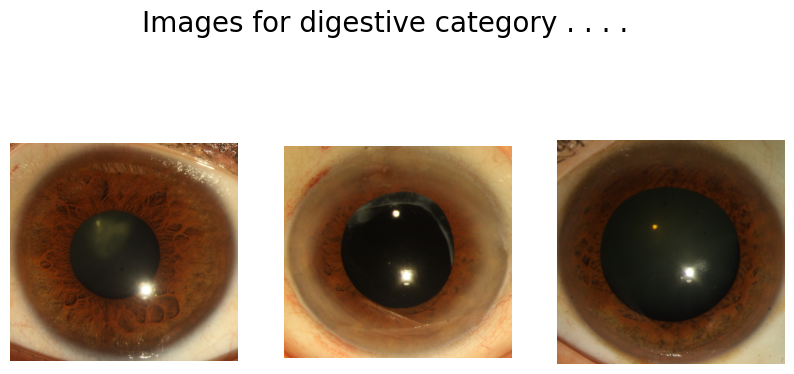

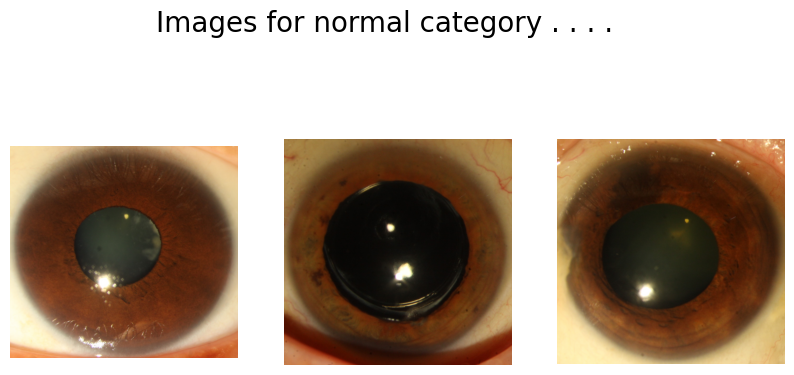

In [ ]:
path = '/content/drive/MyDrive/Research/research_data_set'
classes = ['digestive', 'normal']

#display the images choosing randomly in lungs classes
for cat in classes:
    image_dir = f'{path}/{cat}'
    images = os.listdir(image_dir)

    fig, ax = plt.subplots(1, 3, figsize=(10, 5))
    fig.suptitle(f'Images for {cat} category . . . .', fontsize=20)

    for i in range(3):
        k = np.random.randint(0, len(images))
        img = np.array(Image.open(f'{path}/{cat}/{images[k]}'))
        ax[i].imshow(img)
        ax[i].axis('off')
    plt.show()

In [ ]:
IMG_SIZE = 256
SPLIT = 0.2
EPOCHS = 20
BATCH_SIZE = 64

X = []
Y = []

for i, cat in enumerate(classes):
  images = glob(f'{path}/{cat}/*.JPG')

  for image in images:
    img = cv2.imread(image)

    X.append(cv2.resize(img, (IMG_SIZE, IMG_SIZE)))
    Y.append(i)

X = np.asarray(X)
one_hot_encoded_Y = pd.get_dummies(Y).values

#split the data set into train and validation
X_train, X_val, Y_train, Y_val = train_test_split(X, one_hot_encoded_Y, test_size=SPLIT, random_state=2022)

print(f"Training samples: {X_train.shape[0]}, Validation samples: {X_val.shape[0]}")

Training samples: 235, Validation samples: 59


In [ ]:
# ==========================================
# 3. HYBRID MODEL ARCHITECTURE
# ==========================================
#

input_layer = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

# Branch 1: MobileNetV2
base_mobile = MobileNetV2(input_tensor=input_layer, include_top=False, weights='imagenet')
base_mobile.trainable = False
x1 = layers.GlobalAveragePooling2D()(base_mobile.output)

# Branch 2: ResNet50
base_resnet = ResNet50(input_tensor=input_layer, include_top=False, weights='imagenet')
base_resnet.trainable = False
x2 = layers.GlobalAveragePooling2D()(base_resnet.output)

# Fusion Layer (Concatenation)
combined = layers.Concatenate()([x1, x2])

# Custom Classification Head
x = layers.Dense(512, activation='relu')(combined)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
output = layers.Dense(len(classes), activation='softmax')(x)

model = Model(inputs=input_layer, outputs=output)

/tmp/ipython-input-2424611765.py:9: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_mobile = MobileNetV2(input_tensor=input_layer, include_top=False, weights='imagenet')


In [ ]:
# Compile
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# ==========================================
# 4. TRAINING
# ==========================================
# Callbacks
es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, verbose=1)

In [ ]:
history = model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    verbose=1
)

Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 74s 16s/step - accuracy: 0.5369 - loss: 1.0974 - val_accuracy: 0.4915 - val_loss: 0.8248
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 57s 15s/step - accuracy: 0.6774 - loss: 0.7686 - val_accuracy: 0.5254 - val_loss: 0.6193
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 74s 19s/step - accuracy: 0.6689 - loss: 0.6993 - val_accuracy: 0.6949 - val_loss: 0.5611
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 77s 19s/step - accuracy: 0.7741 - loss: 0.5531 - val_accuracy: 0.7797 - val_loss: 0.5435
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 70s 19s/step - accuracy: 0.8042 - loss: 0.5431 - val_accuracy: 0.7458 - val_loss: 0.5421
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 62s 16s/step - accuracy: 0.7685 - loss: 0.5456 - val_accuracy: 0.7458 - val_loss: 0.5346
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 88s 18s/step - accuracy: 0.7998 - loss: 0.4632 - val_accuracy: 0.7288 - val_loss: 0.5342
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 81s 18s/step - accuracy: 0.8538 - loss: 0.3249 - val_accuracy: 0.7458 - val_loss: 0.5281


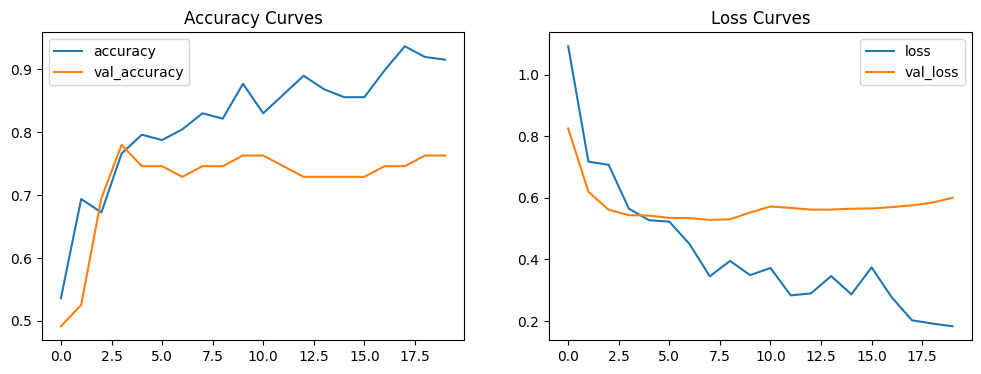

2/2 ━━━━━━━━━━━━━━━━━━━━ 19s 9s/step


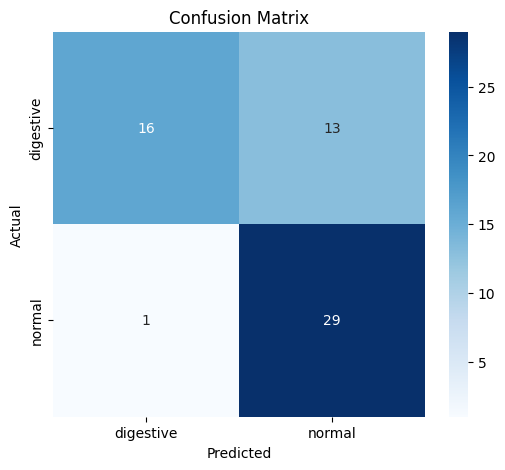

In [ ]:
# ==========================================
# 5. EVALUATION & VISUALIZATION
# ==========================================
# Plot Accuracy and Loss
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
history_df = pd.DataFrame(history.history)

history_df[['accuracy', 'val_accuracy']].plot(ax=ax[0])
ax[0].set_title('Accuracy Curves')

history_df[['loss', 'val_loss']].plot(ax=ax[1])
ax[1].set_title('Loss Curves')
plt.show()

# Confusion Matrix
Y_pred = model.predict(X_val)
Y_pred_classes = np.argmax(Y_pred, axis=1)
Y_true = np.argmax(Y_val, axis=1)

cm = confusion_matrix(Y_true, Y_pred_classes)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()